# Paleolatitude of a basalt dike

Where was Massachusetts when this rock cooled?

A basalt dike in the Middlesex Fells was intruded as molten rock and froze. On
the way through the Curie temperature its magnetic minerals locked in the
direction of the Earth's field at that moment. The steepness of that direction —
the inclination — records latitude: the field lies flat at the equator and
points straight down at the pole.

This notebook walks through recovering that angle from ten transects walked
across the outcrop with a phone magnetometer. The analysis itself lives in the
`dike` package; this is the narrative.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import matplotlib.pyplot as plt

from dike import align, io, plots
from dike.bootstrap import bootstrap_inclination, fit_ar1
from dike.model import fit_dike, paleolatitude_from_inclination
from dike.synthetic import TRUE_PARAMETERS, synthetic_transects

plots.use_house_style()

## The data

Ten CSVs, one per traverse, recorded at 100 Hz. If the survey data is present we
use it; otherwise we fall back to simulated transects with a known answer, so
this notebook runs for anyone who clones the repository.

In [2]:
DATA = Path.cwd().parent / "data" / "high_50cm"

if DATA.exists() and any(DATA.glob("magnetometer_*.csv")):
    transects = io.load_transects(DATA)
    USING_REAL_DATA = True
    print(f"Loaded {len(transects)} field transects.")
else:
    USING_REAL_DATA = False
    transects = [io.calibrate_distance(df) for df in synthetic_transects(seed=0)]
    print("Field data not present — using simulated transects.")
    print(f"True inclination in the simulation: {TRUE_PARAMETERS['inclination']:.1f} deg")

transects[0].head()

Loaded 10 field transects.


,Bx,By,Bz,Btotal,distance
0,22.67,-20.51,-55.30,63.19,0.000000
1,22.67,-20.57,-55.31,63.21,0.000467
2,22.67,-20.58,-55.25,63.17,0.000935
3,22.71,-20.62,-55.23,63.18,0.001402
4,22.79,-20.63,-55.22,63.20,0.001869


## Time becomes distance

The phone records time, not position. Each run was walked between the same two
pegs to a metronome, so elapsed time maps linearly onto the 0.8 m transect.

Plotting the raw runs together shows the first problem: they are the same shape,
stacked at different heights. Each carries its own DC offset — the ambient
regional field plus whatever the phone itself contributes in the orientation it
was held. None of that separation is geological.

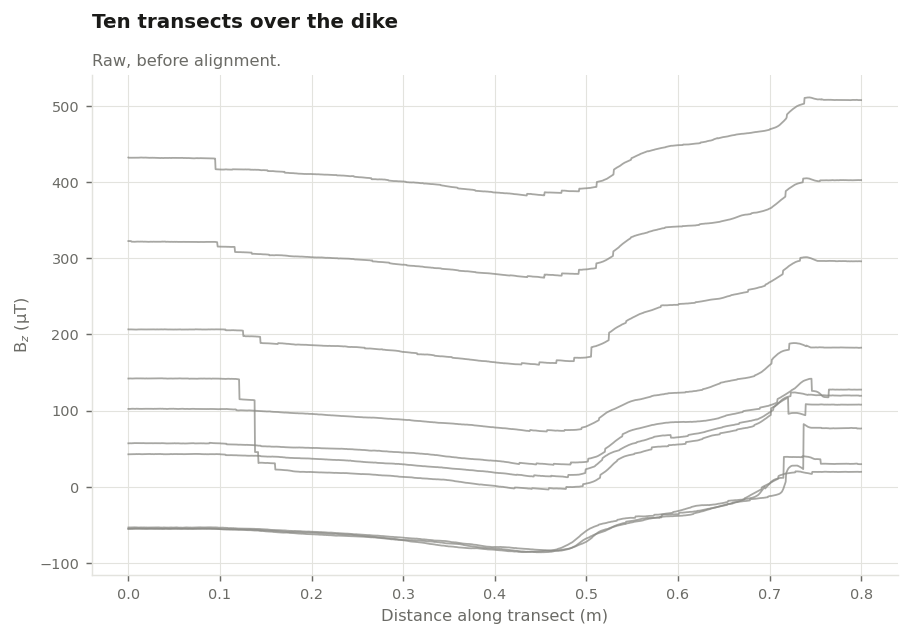

In [3]:
plots.transect_overlay(transects, subtitle="Raw, before alignment.")
plt.show()

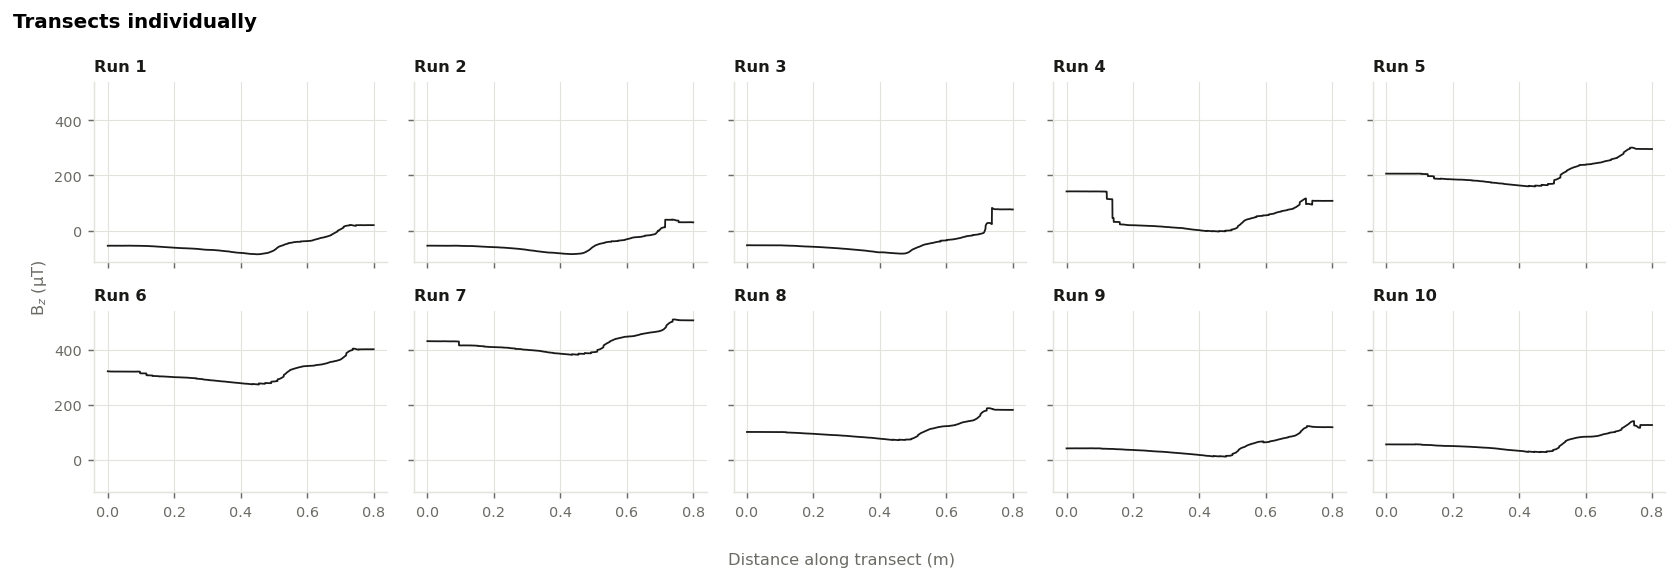

In [4]:
plots.transect_grid(transects)
plt.show()

## Crop and align

Two corrections. The ends of each run are contaminated by starting and stopping,
so they are trimmed to 0.15–0.70 m. Then each run is shifted vertically onto a
common level.

The anchor is the midpoint, for a practical reason: the metronome put a beat
there, so it is the position best known across runs, and unlike the endpoints it
sits where the signal is strong.

The choice of anchor is a real analytical decision. Zeroing at an endpoint — the
obvious-looking option — drags the flanks of the profile to the wrong sign and
degrades the fit badly, which is why `align_transects` offers it but does not
default to it.

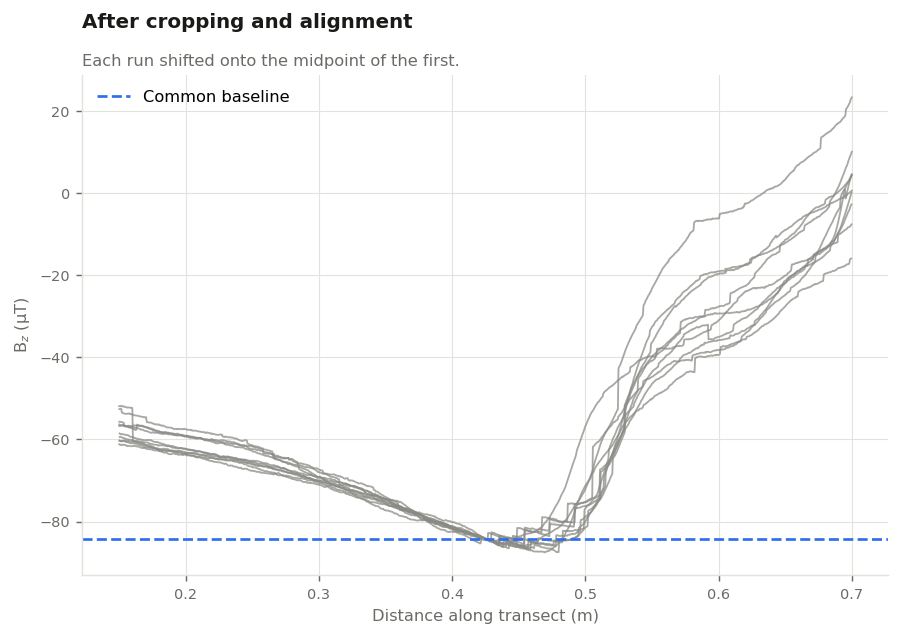

In [5]:
aligned, baseline = align.align_transects(
    transects, start=0.15, end=0.70, at="middle", strategy="reference"
)

plots.transect_overlay(
    aligned,
    title="After cropping and alignment",
    subtitle="Each run shifted onto the midpoint of the first.",
    baseline=baseline,
)
plt.show()

## The model

The vertical anomaly over a two-dimensional dike has a closed form. Two pieces
carry the direction information:

- a **symmetric** pair of arctangent terms, scaled by `sin(inclination)` — a
  vertically magnetised dike gives a symmetric peak;
- an **antisymmetric** logarithmic term, scaled by `cos(inclination)` — a
  horizontally magnetised dike gives a profile that rises on one flank and falls
  on the other.

The balance between the symmetric and antisymmetric shape of the observed
profile is what fixes the inclination.

The fit is bounded so the geometry stays physical. That matters more than it
sounds: a sensor at height *+z* over a dike inclined *−φ* gives exactly the same
curve as a sensor at *−z* over one inclined *+φ*, so an unconstrained fit can
return a negative sensor height — the phone underground — and with it a
sign-flipped inclination, while looking like a perfectly good fit.

In [6]:
x, y = align.pool(aligned)
fit = fit_dike(x, y)
print(fit)

offset      = +0.2852 m
depth       = 0.0257 m
half_width  = 0.2289 m
inclination = -77.90 deg
intensity   = 12.2999
baseline    = +0.0000
R^2         = 0.935
paleolat.   = -66.79 deg


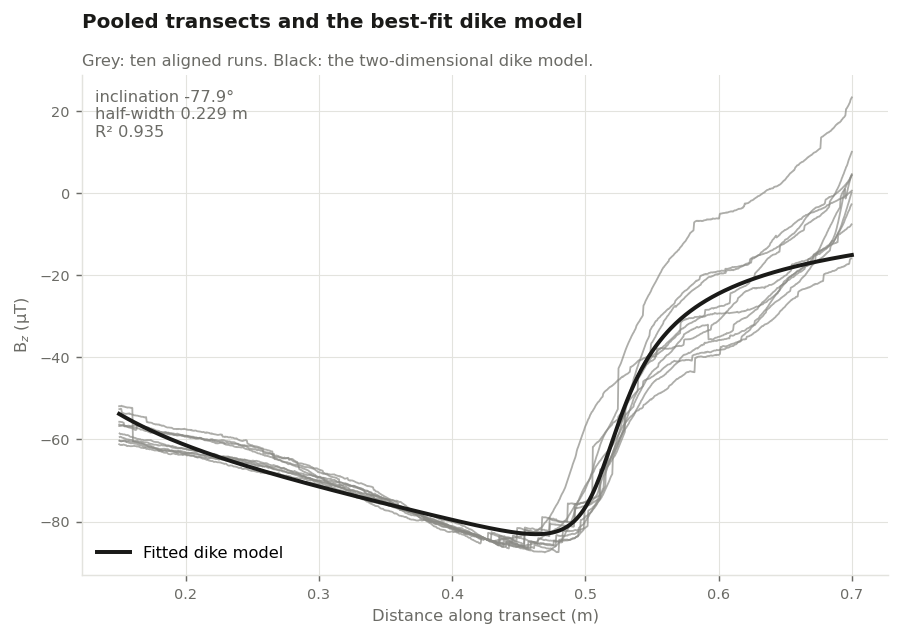

In [7]:
plots.fit_figure(aligned, fit)
plt.show()

## The residuals are not noise

This is the part that changes the answer.

Look at what is left over after subtracting the model. It does not scatter
around zero — it wanders, in long smooth excursions. Consecutive samples are a
hundredth of a second and a few millimetres apart, so they are not independent
observations in any useful sense. The residual is dominated by real spatially
coherent structure: heterogeneity in the outcrop, the operator's hand, the
phone's own drift.

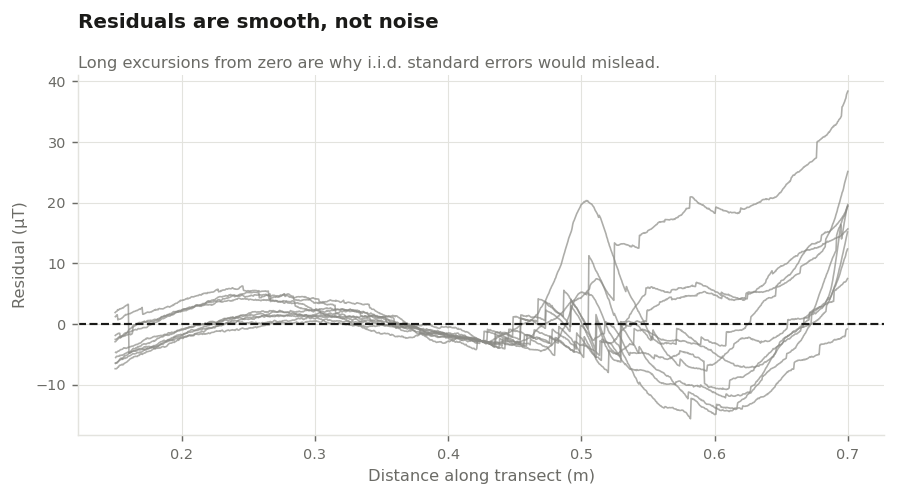

In [8]:
plots.residual_figure(aligned, fit)
plt.show()

In [9]:
residuals = y - fit.predict(x)
ar_model = fit_ar1(residuals)
print(f"AR(1) coefficient: {ar_model.params[1]:.4f}")
print(f"\nNaive standard error on inclination from curve_fit: "
      f"{np.sqrt(np.diag(fit.covariance))[3]:.4f} deg")

AR(1) coefficient: 0.9932

Naive standard error on inclination from curve_fit: 0.2096 deg


That standard error is not believable. It assumes several thousand independent
observations; with an autoregressive coefficient near 0.99 the effective number
is a tiny fraction of that.

So instead: simulate. Generate synthetic profiles from the fitted model plus
simulated AR(1) residuals with the same correlation structure, refit each one,
and look at how much the refitted inclination moves. That spread is an
uncertainty that respects how the data was actually collected.

In [10]:
n_grid = int(np.median([len(df) for df in aligned]))
x_grid = np.linspace(x.min(), x.max(), n_grid)

result = bootstrap_inclination(x_grid, fit.params, ar_model, n_boot=2000, seed=0)
print(result.summary())

replicates      : 2000/2000 converged
inclination     : -77.90 deg (95% CI -85.19 to -69.75)
paleolatitude   : -66.79 deg (95% CI -80.44 to -53.58)


## From angle to latitude

The inclination is not yet the answer. Under the geocentric axial dipole
assumption — that the field, averaged over enough time, is a dipole aligned with
the spin axis — inclination and latitude are related by

$$\tan(I) = 2\tan(\lambda)$$

so the fitted angle and its whole bootstrap distribution can be carried through
to a latitude.

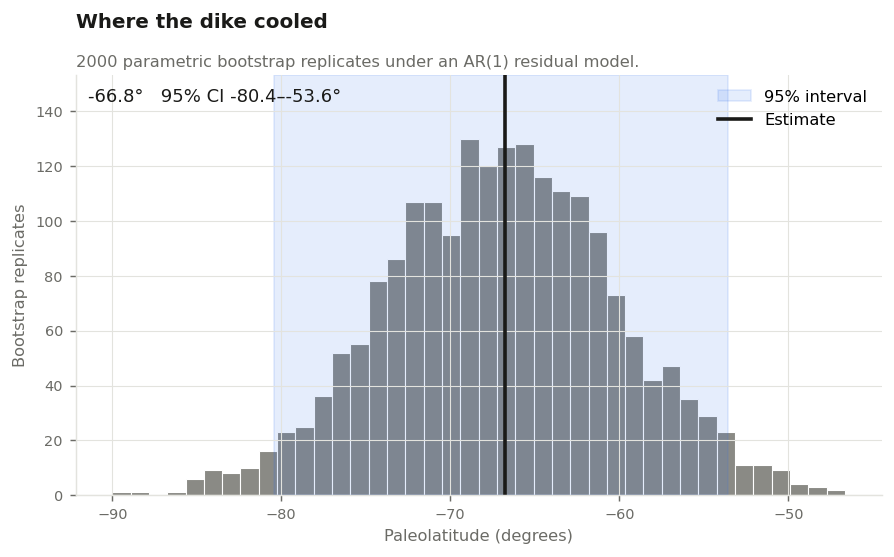

In [11]:
plots.bootstrap_figure(result)
plt.show()

In [12]:
lat_lo, lat_hi = result.interval(result.paleolatitude)
print(f"Paleolatitude: {fit.paleolatitude:.1f} deg  (95% CI {lat_lo:.1f} to {lat_hi:.1f})")

if not USING_REAL_DATA:
    truth = paleolatitude_from_inclination(TRUE_PARAMETERS["inclination"])
    print(f"\nSimulation truth: {truth:.1f} deg")
    print(f"Recovered within the interval: {lat_lo < truth < lat_hi}")

Paleolatitude: -66.8 deg  (95% CI -80.4 to -53.6)


## What this does and does not establish

The pipeline recovers a known answer from simulated data, which is the only
check that means anything in the absence of an independent measurement of this
dike.

What it does not do:

- **One dike records an instant, not an average.** The dipole relation assumes
  the field averaged over enough time. A single intrusion does not average out
  secular variation, so this is a point estimate from one sample of the field,
  not a paleomagnetic pole.
- **The bootstrap covers fit uncertainty only.** It propagates the residual
  process through the fit. It says nothing about error in the distance
  calibration, or in the assumption that the dike is two-dimensional and
  vertically sided.
- **A phone magnetometer has unknown absolute calibration.** Which is why only
  the direction is interpreted, never the intensity.